# Watershed

#### Imports

In [19]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LightSource
from skimage.segmentation import watershed
from skimage.filters import sobel

clr_red   = "#ff0000"
clr_green = "#668f17"
clr_blue  = "#40acde"

## Représentations 2D et 3D

In [2]:
# Image
img = io.imread("oblur.png")
N = img.shape[0]
print(img.shape)

(250, 250)


In [3]:
# Préparation de l'affichage 3D
ls = LightSource(270, 45)
x, y = np.meshgrid(range(N), range(N))
z = img.T

# To use a custom hillshading mode, override the built-in shading and pass
# in the rgb colors of the shaded surface calculated from "shade".
rgb = ls.shade(z, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')

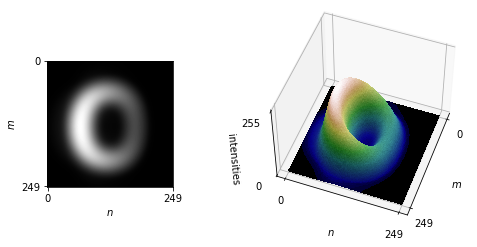

In [4]:
# Figure
fig = plt.figure(figsize=(10, 5), facecolor='w')

# Image 2D
ax2d = fig.add_axes([0,.3,.3,.35])
ax2d.imshow(img, "gray")
ax2d.set_xlabel('$n$')
ax2d.set_ylabel('$m$')
ax2d.set_xticks([0, N-1])
ax2d.set_yticks([0, N-1])

# Image 3D
ax3d = fig.add_axes([.2,.2,.6,.6], projection='3d')
surf = ax3d.plot_surface(x, y, z, rstride=1, cstride=1, facecolors=rgb,
                         linewidth=0, antialiased=False, shade=False)
ax3d.view_init(elev=50, azim=20)
ax3d.set_xlabel('$m$')
ax3d.set_ylabel('$n$')
ax3d.set_zlabel('intensities')
ax3d.set_xticks([0, N-1])
ax3d.set_yticks([0, N-1])
ax3d.set_zticks([0, 255])

# Finalisation
plt.savefig("watershed-concept.svg", bbox_inches='tight', transparent=False)
plt.show()

## Watershed sur l'image simple

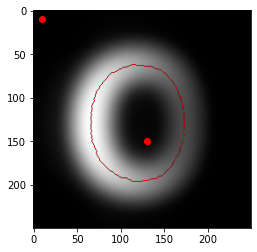

In [5]:
# Marqueurs
coords = np.array([[10,10], [150, 130]])
markers = np.zeros((N,N), dtype=np.int32)
i = 0
for c in coords:
    i += 1
    markers[c[0],c[1]] = i

# Watershed
labels = watershed(img, markers=markers, mask=np.ones((N,N)), watershed_line=True)

# Image des contours
borders = np.zeros((N, N, 4))
borders[labels==0] = [1, 0, 0, 1]

# Affichage
plt.figure(figsize=(4,4))
plt.imshow(img, "gray")
plt.imshow(borders)
plt.scatter(coords[:,1], coords[:,0], color=clr_red)
plt.show()

## Montée des eaux sur une coupe de l'image simple

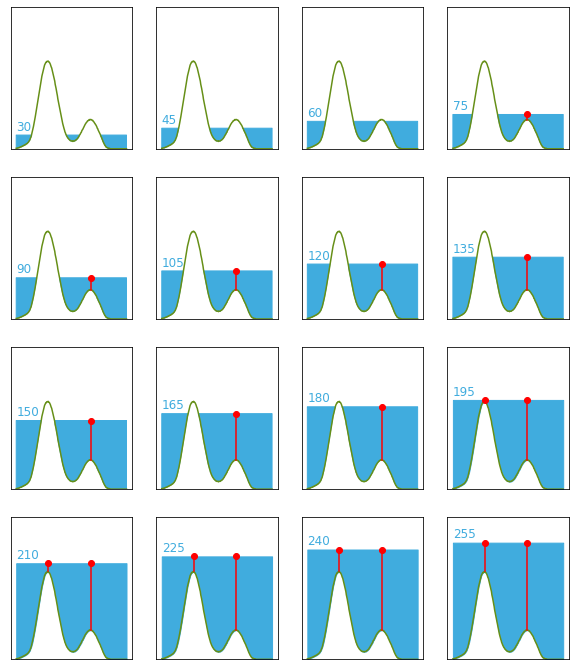

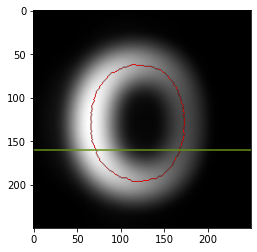

In [7]:
# Coupe
row = 160

# Coupe de l'image
f = img[row,:]

# Coupe des labels
dams = np.where( labels[row,:]==0 )[0]

# Animation
levels = range(30, 256, 15)
K = len(levels)
rows = np.ceil(K/4).astype('int')
fig = plt.figure(figsize=(10,3*rows))
for k in range(K):

    level = levels[k]

    ax = fig.add_subplot(rows, 4, k+1)
    
    # Affichage de la coupe de l'image
    ax.plot(f, color=clr_green)

    # Affichage de l'eau
    g = np.minimum(f, level, dtype=np.float64)
    g[f > level] = np.nan
    ax.fill_between(range(N), g, level, color=clr_blue)

    # Niveau de l'eau
    plt.text(0, level+10, f"{level}", color=clr_blue, size=12)

    # Affichage des dams
    for d in dams:
        y = f[d]
        if level < y:
            continue
        ax.plot([d, d], [y, level], 'r-')
        ax.plot(d, level, 'ro')

    ax.set_ylim([0, 310])
    ax.set_xticks([])
    ax.set_yticks([])

# Finalisation
plt.savefig("watershed-animation.svg", bbox_inches="tight")
plt.show()

# Coupe sur l'image
plt.figure(figsize=(4,4))
plt.imshow(img,"gray")
plt.plot([0, N],[row, row],color=clr_green)
plt.imshow(borders)
plt.savefig("watershed-cut.svg", bbox_inches="tight")
plt.show()

## Image de cellules

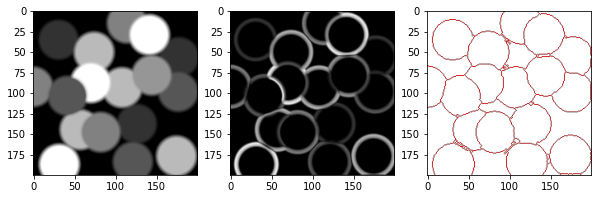

In [79]:
# Image
img = io.imread("cells3.png")
N = img.shape[0]

# Contours
edges = sobel(img)

# Watershed
labels = watershed(edges, mask=np.ones((N,N)), watershed_line=True)

# Image des contours
borders = np.zeros((N, N, 4))
borders[labels==0] = [1, 0, 0, 1]

# Affichage
fig, axs = plt.subplots(1,3,figsize=(10,5))
axs[0].imshow(img, "gray")
axs[1].imshow(edges, "gray")
axs[2].imshow(borders)
plt.savefig("cells-watershed-ok.svg", bbox_inches="tight")
plt.show()

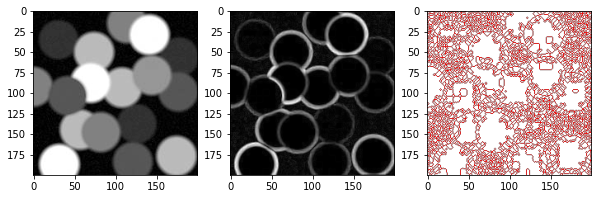

In [80]:
# Image
img = io.imread("cells3.jpg")
N = img.shape[0]

# Contours
edges = sobel(img)

# Watershed
labels = watershed(edges, mask=np.ones((N,N)), watershed_line=True)

# Image des contours
borders = np.zeros((N, N, 4))
borders[labels==0] = [1, 0, 0, 1]

# Affichage
fig, axs = plt.subplots(1,3,figsize=(10,5))
axs[0].imshow(img, "gray")
axs[1].imshow(edges, "gray")
axs[2].imshow(borders)
plt.savefig("cells-watershed-oversegmentation.svg", bbox_inches="tight")
plt.show()

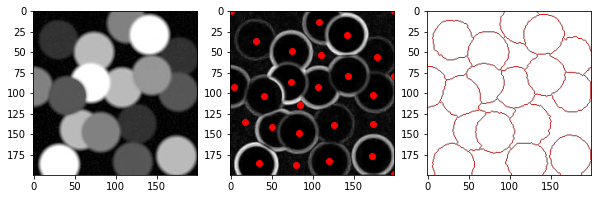

In [81]:
# Image
img = io.imread("cells3.jpg")
N = img.shape[0]

# Marqueurs
markers = np.zeros((N,N), dtype=np.int32)
coords = np.array([
    [37,31], [49,75], [13,108], [29,142], [93,4], [104,40], [86,73], [93,107], [79,143], [56,178], [102,174], [141,50], [148,83], [139,126], [185,34], [183,120], [176,172],
    [0,0], [54,110], [137,174], [187,80], [135,17], [0,199], [199,199], [115,84], [79,199]
                  ])

i = 0
for c in coords:
    i += 1
    markers[c[0],c[1]] = i

# Contours
edges = sobel(img)

# Watershed
labels = watershed(edges, markers=markers, mask=np.ones((N,N)), watershed_line=True)

# Image des contours
borders = np.zeros((N, N, 4))
borders[labels==0] = [1, 0, 0, 1]

# Affichage
fig, axs = plt.subplots(1,3,figsize=(10,5))
axs[0].imshow(img, "gray")
axs[1].imshow(edges, "gray")
axs[1].scatter(coords[:,1], coords[:,0], color=clr_red)
axs[2].imshow(borders)
plt.savefig("cells-watershed-markers.svg", bbox_inches="tight")
plt.show()

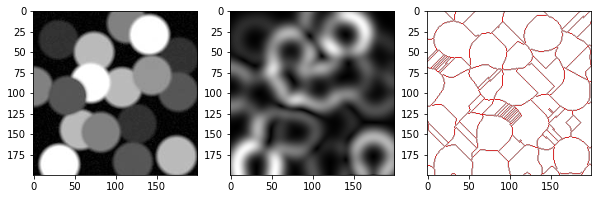

In [82]:
# Image
img = io.imread("cells3.jpg")
smoothed = gaussian(img,8)
N = img.shape[0]

# Contours
edges = sobel(smoothed)

# Watershed
labels = watershed(edges, mask=np.ones((N,N)), watershed_line=True)

# Image des contours
borders = np.zeros((N, N, 4))
borders[labels==0] = [1, 0, 0, 1]

# Affichage
fig, axs = plt.subplots(1,3,figsize=(10,5))
axs[0].imshow(img, "gray")
axs[1].imshow(edges, "gray")
axs[2].imshow(borders)
plt.savefig("cells-watershed-smooth.svg", bbox_inches="tight")
plt.show()